# Autoregressive Conditional Heteroskedasticity (ARCH)
- periods of high volatility are followed by periods of even higher volatility
- periods of low volatility are followed by periods of even lower volatility

In practice this means that volatility tends to cluster.

## GARCH
- error varince is thought to be autocorrelated over time
- assume the variance of the error term follows a process based on an autoregressive moving average
- supposed to capture better long-term volatility patterns

## ARCH(q) == GARCH(0, q)

In [10]:
import numpy as np
from arch import arch_model
import pandas as pd
import matplotlib.pyplot as plt
import json

import sys
import os

sys.path.append(os.path.abspath('..'))
from functions import line_plot, mse, mae, rmse, mape, mase, pred_char_to_value

import warnings
warnings.filterwarnings("ignore")

from tqdm import tqdm
from statsmodels.graphics.tsaplots import plot_pacf

In [11]:
df = pd.read_csv('../Data/aluminium_pre_inputs.csv')

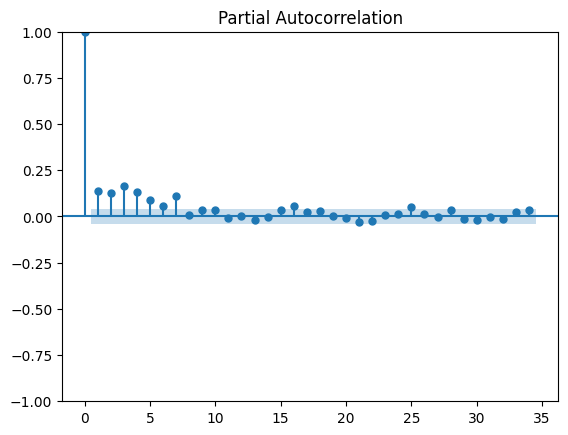

In [12]:
# Partial AutoCorrelation Function
plot_pacf(df['al_lme_prices_log_returns']**2)
plt.show()

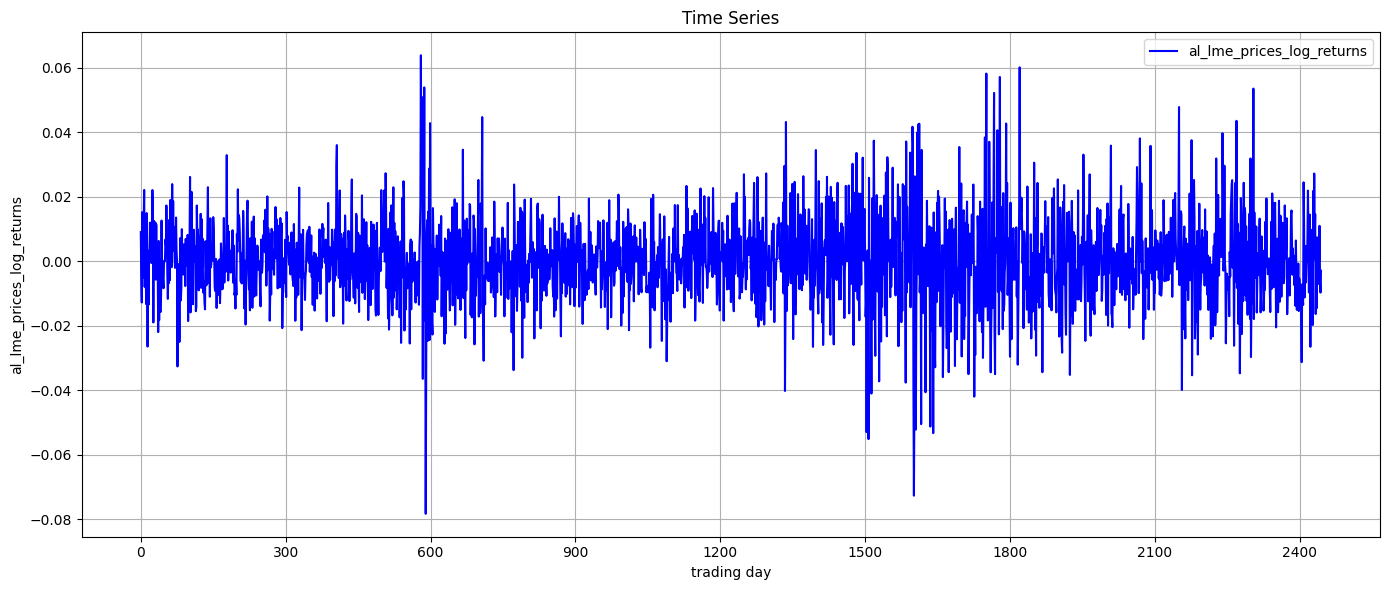

(<Axes: title={'center': 'Time Series'}, xlabel='trading day', ylabel='al_lme_prices_log_returns'>,
 <Figure size 1400x600 with 1 Axes>)

In [4]:
line_plot(df['date'], df['al_lme_prices_log_returns'], 'al_lme_prices_log_returns')

In [9]:
# find the right garch model
for p,q in [(1,1),(1,2),(2,1),(2,2),(7,1),(7,2)]:
    model = arch_model(df['al_lme_prices_log_returns'], p=p, q=q)
    model_fit = model.fit()
    print('\n', f'(p, q) = {(p, q)}')
    print(model_fit.summary())

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1.78538088228808e+19
Iteration:      2,   Func. Count:     18,   Neg. LLF: 6678711652977.094
Iteration:      3,   Func. Count:     33,   Neg. LLF: 2569199706185.8184
Iteration:      4,   Func. Count:     48,   Neg. LLF: 8311227.711332761
Iteration:      5,   Func. Count:     61,   Neg. LLF: 127414605072608.45
Iteration:      6,   Func. Count:     76,   Neg. LLF: 8410377525749418.0
Iteration:      7,   Func. Count:     91,   Neg. LLF: 3.787839262451902e+16
Iteration:      8,   Func. Count:    106,   Neg. LLF: 47288962.22653342
Iteration:      9,   Func. Count:    119,   Neg. LLF: 20866785266096.31
Iteration:     10,   Func. Count:    134,   Neg. LLF: 99807205338299.2
Iteration:     11,   Func. Count:    149,   Neg. LLF: 17368105.61331532
Iteration:     12,   Func. Count:    161,   Neg. LLF: -7257.811096720794
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7257.811104477106
            Itera

In [7]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=2, q=1)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      7,   Neg. LLF: 3.096578870186174e+19
Iteration:      2,   Func. Count:     20,   Neg. LLF: 476315705.1130686
Iteration:      3,   Func. Count:     33,   Neg. LLF: 1.9228440836425508e+23
Iteration:      4,   Func. Count:     49,   Neg. LLF: 71698327353.30222
Iteration:      5,   Func. Count:     58,   Neg. LLF: 1062015025.5697104
Iteration:      6,   Func. Count:     71,   Neg. LLF: 452276727861.14594
Iteration:      7,   Func. Count:     86,   Neg. LLF: 11141907239.706158
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7255.578497960494
            Iterations: 10
            Function evaluations: 96
            Gradient evaluations: 7




<class 'statsmodels.iolib.summary.Summary'>
"""
                         Constant Mean - GARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GARCH   Log-Likelihood:                7255.58
Distribution:                         Normal   AIC:                          -14501.2
Method:                   Maximum Likelihood   BIC:                          -14472.1
                                               No. Observations:                 2445
Date:                       Thu, Sep 18 2025   Df Residuals:                     2444
Time:                               12:29:28   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         3.0522e-04  2.462e-04      1.240      0.215 [-1.773e-04,7.877e-04]
                               Volatility Model                              
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
omega      3.5288e-06  1.435e-11  2.459e+05      0.000  [3.529e-06,3.529e-06]
alpha[1]       0.0250  1.724e-02      1.448      0.148 [-8.827e-03,5.876e-02]
alpha[2]       0.0250  1.472e-02      1.696  8.986e-02 [-3.884e-03,5.382e-02]
beta[1]        0.9288  4.015e-03    231.323      0.000      [  0.921,  0.937]
=============================================================================

Covariance estimator: robust
"""

In [40]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=2, q=0)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 389461259.62260467
Iteration:      2,   Func. Count:     18,   Neg. LLF: -7065.873296233498
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7065.873287047682
            Iterations: 6
            Function evaluations: 18
            Gradient evaluations: 2




<class 'statsmodels.iolib.summary.Summary'>
"""
                          Constant Mean - ARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                              ARCH   Log-Likelihood:                7065.87
Distribution:                         Normal   AIC:                          -14123.7
Method:                   Maximum Likelihood   BIC:                          -14100.5
                                               No. Observations:                 2445
Date:                       Sat, Aug 09 2025   Df Residuals:                     2444
Time:                               15:07:01   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         1.4695e-04  2.734e-04      0.538      0.591 [-3.888e-04,6.827e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      8.8326e-05  3.636e-06     24.289 2.539e-130 [8.120e-05,9.545e-05]
alpha[1]       0.1000  2.162e-02      4.624  3.758e-06   [5.762e-02,  0.142]
alpha[2]       0.1000  2.102e-02      4.756  1.970e-06   [5.879e-02,  0.141]
============================================================================

Covariance estimator: robust
"""

In [41]:
# find the right garch model
model = arch_model(df['al_lme_prices_log_returns'], p=1, q=1)
model_fit = model.fit()
print('\n')
model_fit.summary()

Iteration:      1,   Func. Count:      6,   Neg. LLF: 1.785381037053394e+19
Iteration:      2,   Func. Count:     18,   Neg. LLF: 176719254091.15552
Iteration:      3,   Func. Count:     32,   Neg. LLF: 2507788696427.126
Iteration:      4,   Func. Count:     47,   Neg. LLF: 8105588.046827351
Iteration:      5,   Func. Count:     59,   Neg. LLF: -7257.8118957825645
Optimization terminated successfully    (Exit mode 0)
            Current function value: -7257.811903534157
            Iterations: 9
            Function evaluations: 59
            Gradient evaluations: 5




<class 'statsmodels.iolib.summary.Summary'>
"""
                         Constant Mean - GARCH Model Results                         
=====================================================================================
Dep. Variable:     al_lme_prices_log_returns   R-squared:                       0.000
Mean Model:                    Constant Mean   Adj. R-squared:                  0.000
Vol Model:                             GARCH   Log-Likelihood:                7257.81
Distribution:                         Normal   AIC:                          -14507.6
Method:                   Maximum Likelihood   BIC:                          -14484.4
                                               No. Observations:                 2445
Date:                       Sat, Aug 09 2025   Df Residuals:                     2444
Time:                               15:07:03   Df Model:                            1
                                  Mean Model                                 
=============================================================================
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
mu         2.7775e-04  1.684e-04      1.649  9.915e-02 [-5.238e-05,6.079e-04]
                              Volatility Model                              
============================================================================
                 coef    std err          t      P>|t|      95.0% Conf. Int.
----------------------------------------------------------------------------
omega      3.5331e-06  8.384e-13  4.214e+06      0.000 [3.533e-06,3.533e-06]
alpha[1]       0.0500  8.452e-03      5.916  3.306e-09 [3.343e-02,6.657e-02]
beta[1]        0.9300  7.136e-03    130.320      0.000     [  0.916,  0.944]
============================================================================

Covariance estimator: robust
"""

In [14]:
horizon_char = ['1w', '1m', '3m', '1y']
horizon_vals = [5, 22, 66, 252]

In [15]:
def test_garch(p, q, horizon_char=horizon_char, horizon_vals=horizon_vals):
    hashMap = {i: [] for i in horizon_vals}
    context_window_vals = [5, 10, 20, 50, 100, 200, 500, 1000]
    for i, (horizon_pred, col_name) in enumerate(zip(horizon_vals, horizon_char)):
        losses = []
        for context_window in context_window_vals:
            print(f'{i+1}/{len(horizon_vals)}, cw = {context_window}, horizon = {horizon_vals[i]}')
            
            vols_pred = []
            for idx in tqdm(range(context_window, df.shape[0])):

                returns_window = df['al_lme_prices_log_returns'][idx-context_window:idx]*100
                model = arch_model(returns_window, vol='Garch', p=p, q=q, dist='normal', mean='constant', rescale=False)
                res = model.fit(disp='off')
                forecast = res.forecast(horizon=horizon_pred)
                
                next_volatility = np.sqrt(252)*np.sqrt(forecast.variance.values[0][-1])/100
                vols_pred.append(next_volatility)

            true_vol = df[f'{col_name}_vol'][context_window:]
            vols_pred = np.array(vols_pred)

            losses.append(mape(true_vol, vols_pred))
            print(context_window, '->', mape(true_vol, vols_pred))
        hashMap[horizon_pred] = losses

    cw_df = pd.DataFrame.from_dict(hashMap)
    cw_df.index = context_window_vals
    cw_df = cw_df.sort_index(axis=1)
    cw_df.to_csv(f'GARCH{p}{q}.csv', index=True)
    print(f'p = {p}, q = {q}\n', cw_df)

In [ ]:
values = [(2,2),(2,1),(2,0),(1,1)]
values = [(1,1)]
for p, q in values:
    test_garch(p, q)

1/4, cw = 5, horizon = 5


100%|██████████| 2440/2440 [00:44<00:00, 54.31it/s]


5 -> 28.735217608197484
1/4, cw = 10, horizon = 5


100%|██████████| 2435/2435 [00:41<00:00, 58.43it/s]


10 -> 25.702551030261827
1/4, cw = 20, horizon = 5


...

100%|██████████| 2425/2425 [00:44<00:00, 54.33it/s]


20 -> nan
3/4, cw = 50, horizon = 66


100%|██████████| 2395/2395 [00:43<00:00, 54.97it/s]


50 -> nan
3/4, cw = 100, horizon = 66


  6%|▌         | 131/2345 [00:03<00:52, 42.13it/s]

In [50]:
bestp = 2
bestq = 1

pred_volatilities = {i:[] for i in horizon_char}
avg_pred_volatilities = {i:[] for i in horizon_char}

for i, (horizon_pred, col_name) in enumerate(zip(horizon_vals, horizon_char)):
    context_window = horizon_pred*2
    print(f'{i+1}/{len(horizon_vals)}, cw = {context_window}, horizon = {horizon_vals[i]}')
    
    vols_pred = []
    avg_vols_pred = []
    for idx in tqdm(range(context_window, df.shape[0])):

        returns_window = df['al_lme_prices_log_returns'][idx-context_window:idx]*100
        model = arch_model(returns_window, vol='Garch', p=bestp, q=bestq, dist='normal', mean='constant', rescale=False)
        res = model.fit(disp='off')
        forecast = res.forecast(horizon=horizon_pred)
        # Take the forecast at the horizon step (last forecast)
        next_volatility = np.sqrt(252)*np.sqrt(forecast.variance.values[0][-1])/100
        avg_next_volatility = np.sqrt(252)*np.sqrt(np.mean(forecast.variance.values[0]))/100
        vols_pred.append(next_volatility)
        avg_vols_pred.append(avg_next_volatility)

    # true_vol = df[f'{col_name}_vol'][context_window:]
    vols_pred = np.array(vols_pred)   # scale if needed

    pred_volatilities[col_name] = vols_pred
    avg_pred_volatilities[col_name] = avg_vols_pred

with open("pred_volatilities.json", "w") as f:
    json.dump({k: list(map(float, v)) for k, v in pred_volatilities.items()}, f, indent=4)

with open("avg_pred_volatilities.json", "w") as f:
    json.dump({k: list(map(float, v)) for k, v in avg_pred_volatilities.items()}, f, indent=4)

1/4, cw = 10, horizon = 5


100%|██████████| 2435/2435 [00:30<00:00, 79.20it/s]


2/4, cw = 44, horizon = 22


100%|██████████| 2401/2401 [00:34<00:00, 70.40it/s]


3/4, cw = 132, horizon = 66


100%|██████████| 2313/2313 [00:37<00:00, 62.28it/s]


4/4, cw = 504, horizon = 252


100%|██████████| 1941/1941 [00:31<00:00, 61.70it/s]


In [51]:
# metrics
with open("avg_pred_volatilities.json", "r") as f:
    avg_pred_volatilities_test = json.load(f)

In [52]:
metric_names = ['MAPE', 'MAE', 'MSE', 'RMSE', 'MASE']
metrics_df = pd.DataFrame(columns=['Expiry'] + metric_names)

for expiry_date, vals in avg_pred_volatilities_test.items():
    metrics = []
    for metric in [mape, mae, mse, rmse, mase]:
        true_vol = df[f'{expiry_date}_vol'][pred_char_to_value(expiry_date) * 2:]
        assert len(true_vol) == len(vals), f"Length mismatch for {expiry_date}"
        res = metric(vals, true_vol)
        # print(f'{metric.__name__} for {expiry_date}: {res:.4f}')
        metrics.append(res)

    metrics_df.loc[len(metrics_df)] = [expiry_date] + metrics


metrics_df.to_csv('garch_forecast_metrics.csv', index=False)

metrics_df

,Expiry,MAPE,MAE,MSE,RMSE,MASE
0,1w,54.082755,0.040138,0.003477,0.058970,1.035072
1,1m,11.077600,0.023569,0.002409,0.049079,1.673864
2,3m,8.462542,0.018437,0.000842,0.029018,3.478534
3,1y,11.745629,0.023955,0.000910,0.030166,9.272315


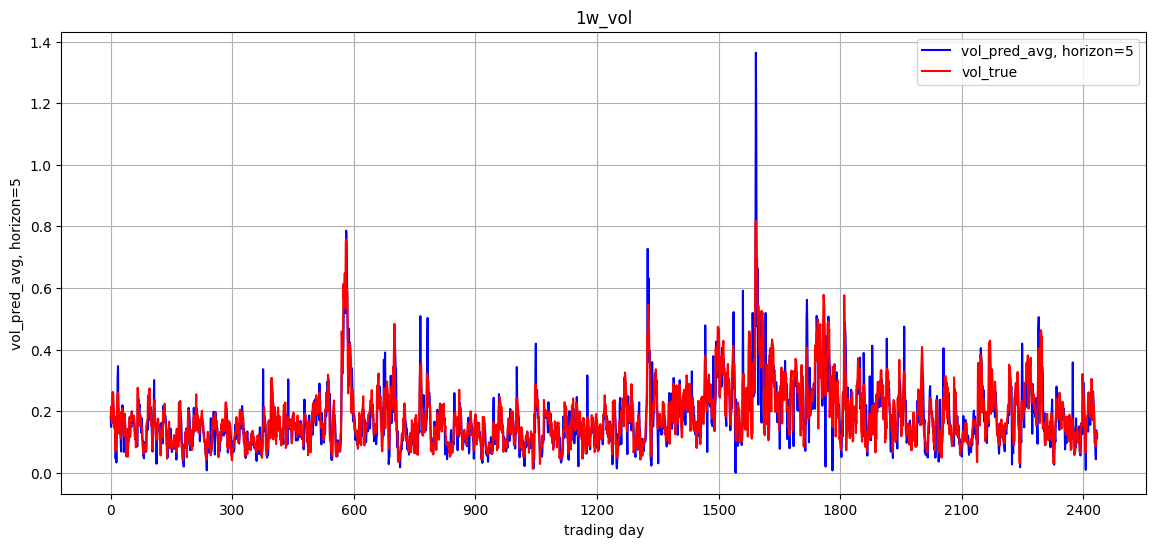

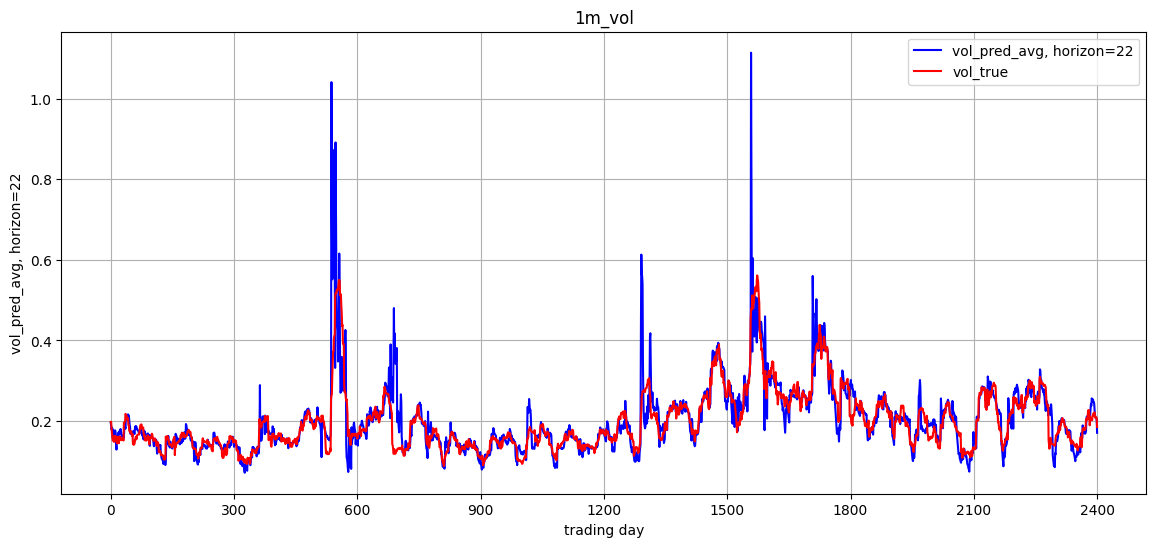

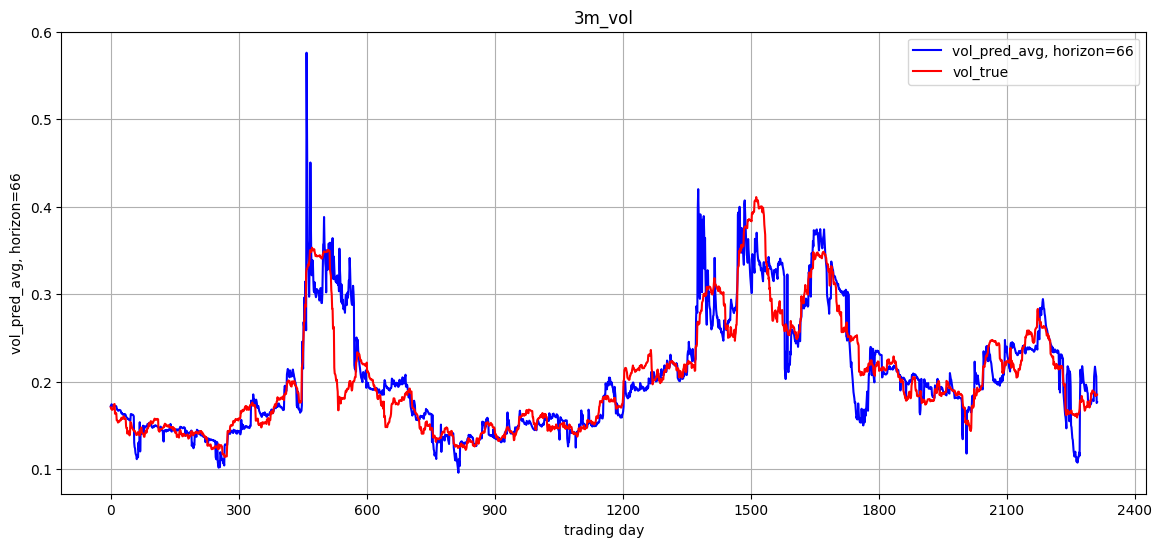

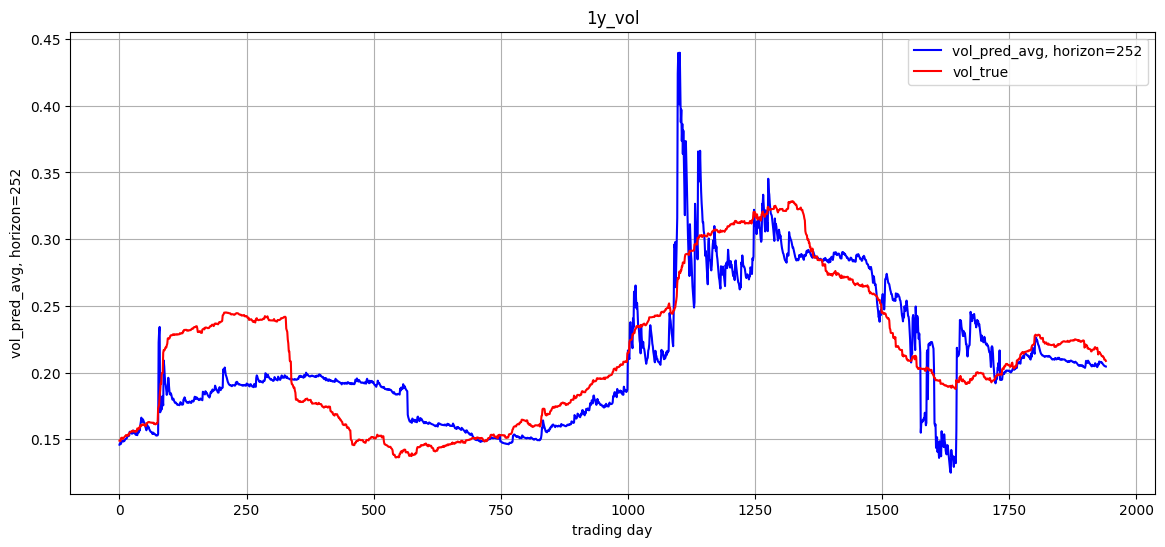

In [53]:
os.makedirs('volatility_plots', exist_ok=True)

for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], vals, f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', graphtitle=f'{expiry_date}_vol', show=False)
    _, _ = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], df[f'{expiry_date}_vol'][2*pred_char_to_value(expiry_date):], 'vol_true', linecolor='red', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_true_garch.png', dpi=300)
    plt.close(fig)

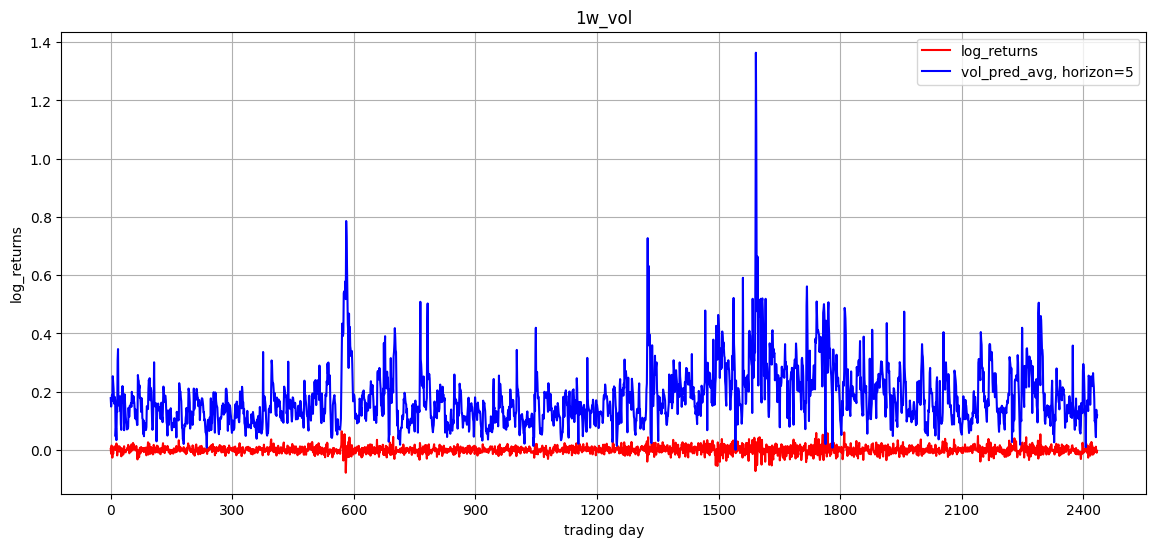

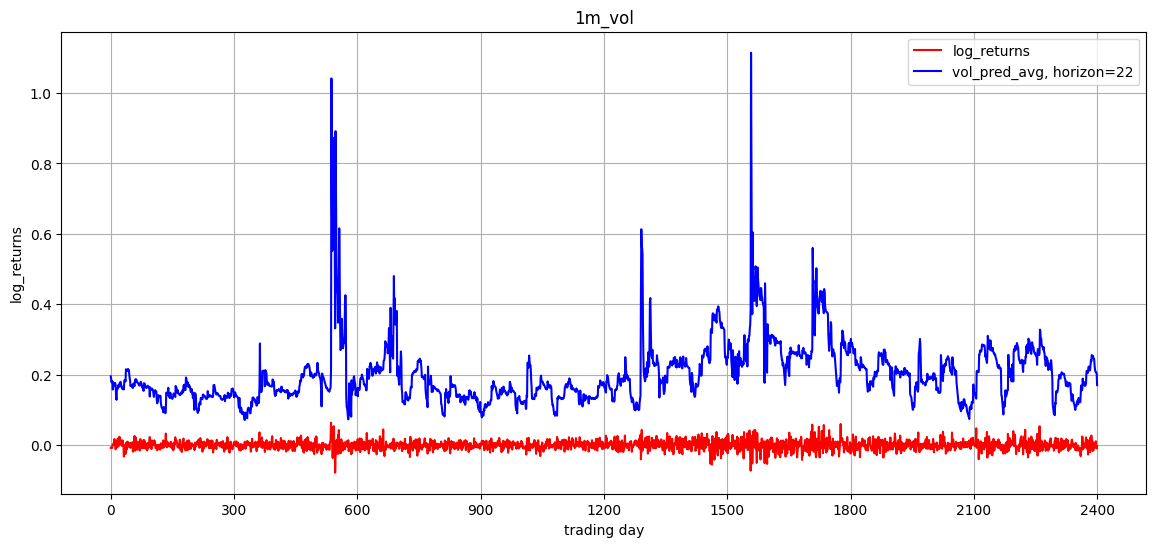

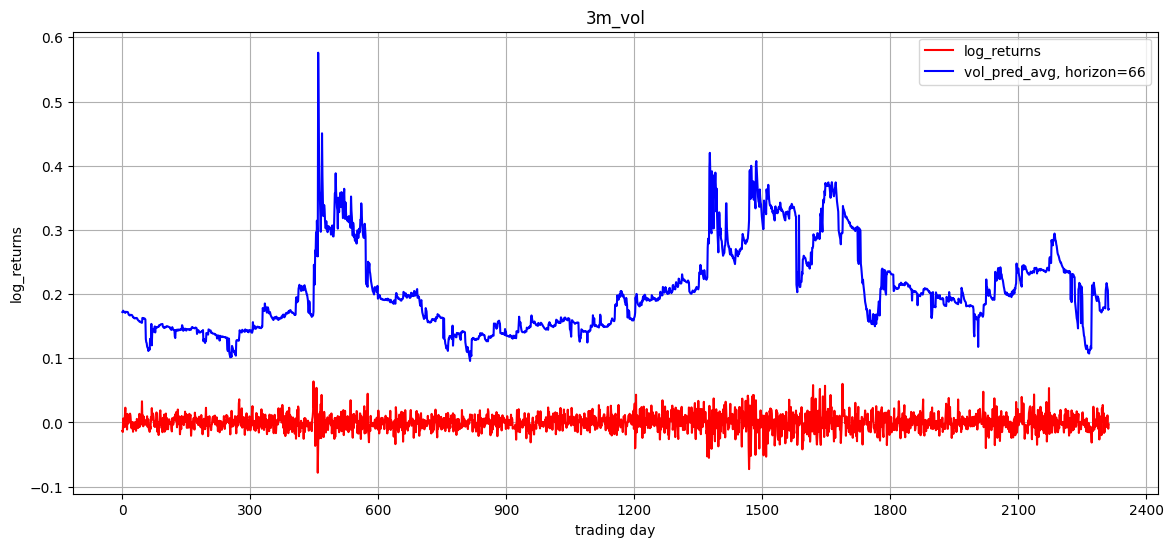

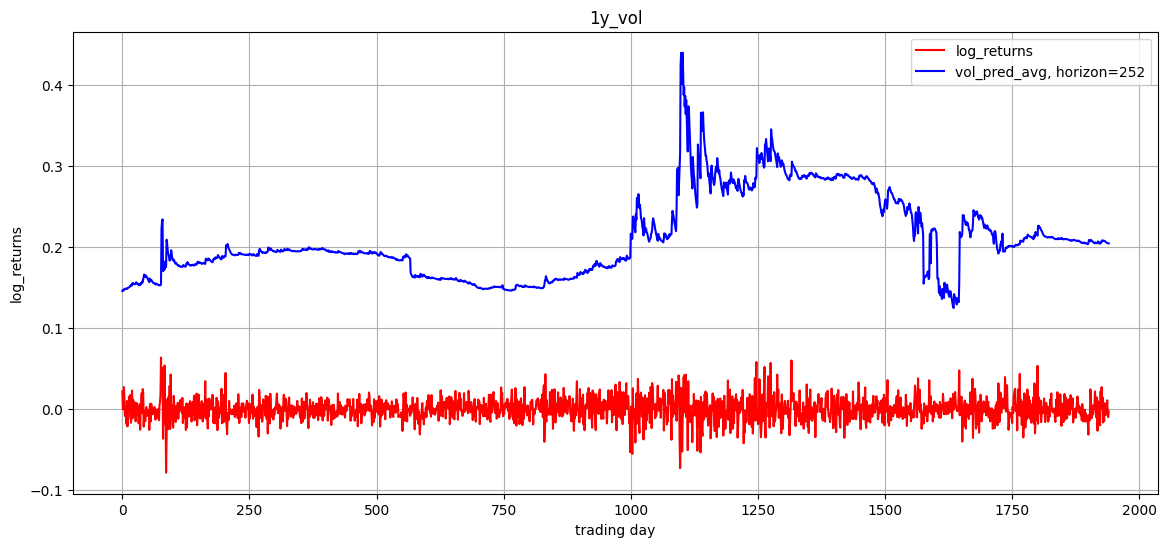

In [54]:
for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], df[f'al_lme_prices_log_returns'][2*pred_char_to_value(expiry_date):], 'log_returns', graphtitle=f'{expiry_date}_vol', linecolor='red', show=False)
    _, _ = line_plot(df['date'][pred_char_to_value(expiry_date) * 2:], vals, f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_log_returns_garch.png', dpi=300)
    plt.close(fig)

# Fair metrics - last 20%

In [55]:
# last 488
metric_names = ['MAPE', 'MAE', 'MSE', 'RMSE', 'MASE']
metrics_df = pd.DataFrame(columns=['Expiry'] + metric_names)

for expiry_date, vals in avg_pred_volatilities_test.items():
    metrics = []
    for metric in [mape, mae, mse, rmse, mase]:
        true_vol = df[f'{expiry_date}_vol'][-488+pred_char_to_value(expiry_date):]
        vals = vals[-488+pred_char_to_value(expiry_date):]
        assert len(true_vol) == len(vals), f"Length mismatch for {expiry_date}"
        res = metric(vals, true_vol)
        metrics.append(res)

    metrics_df.loc[len(metrics_df)] = [expiry_date] + metrics


metrics_df.to_csv('garch_forecast_metrics_fair.csv', index=False)

metrics_df

,Expiry,MAPE,MAE,MSE,RMSE,MASE
0,1w,28.608248,0.039059,0.003147,0.056097,1.020863
1,1m,11.578538,0.020419,0.000733,0.027074,1.981958
2,3m,8.744305,0.016558,0.000444,0.021072,3.175788
3,1y,4.640958,0.009712,0.000130,0.011417,8.405413


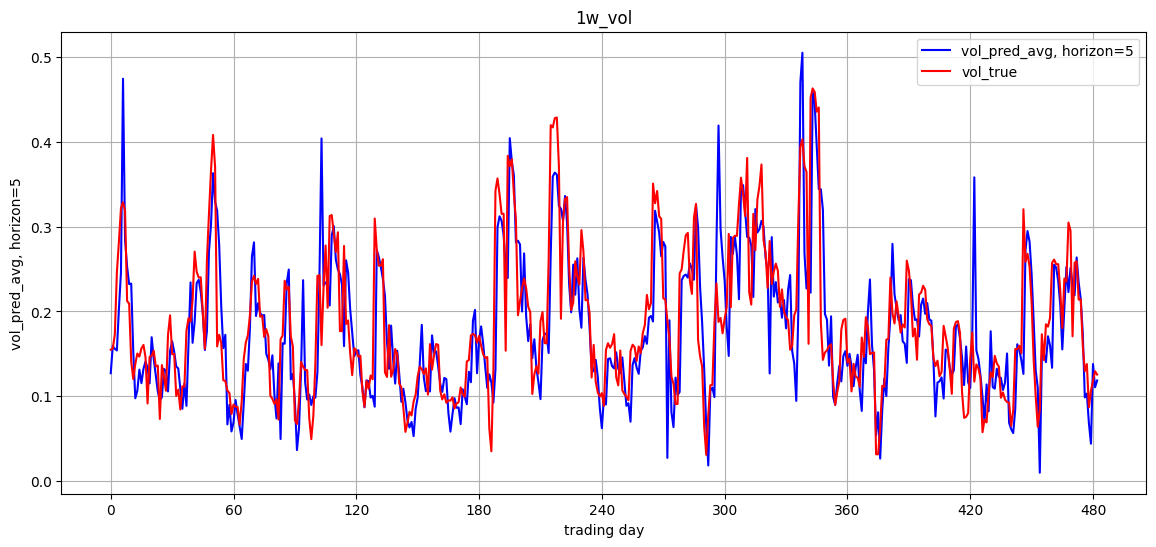

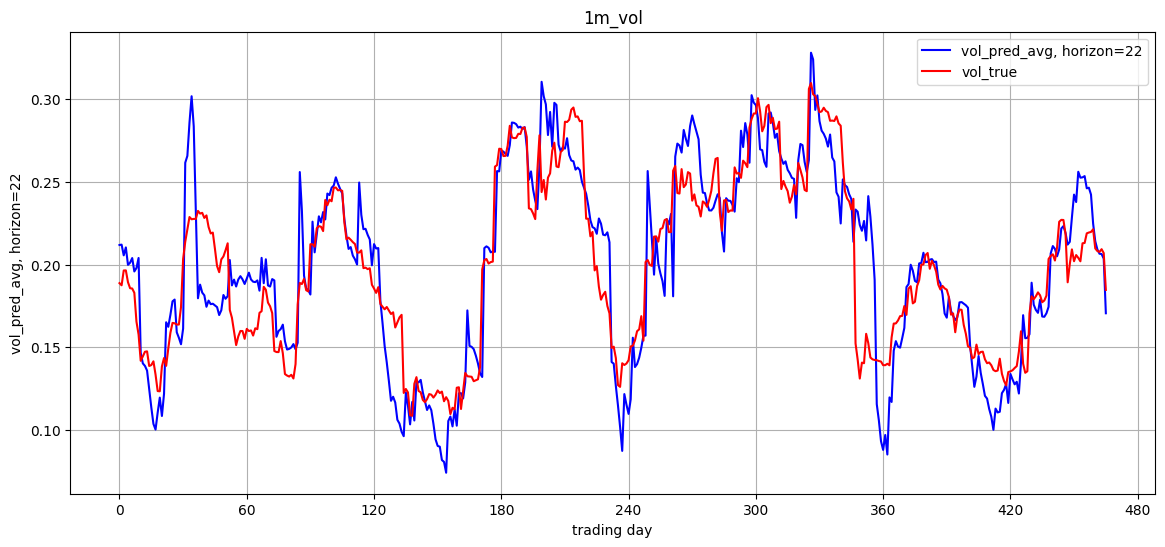

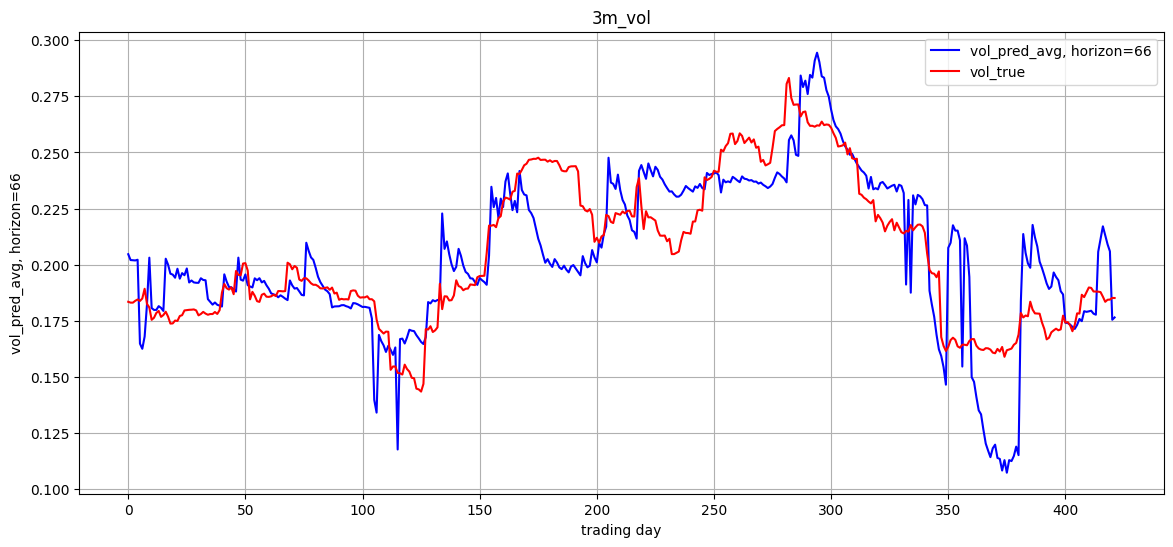

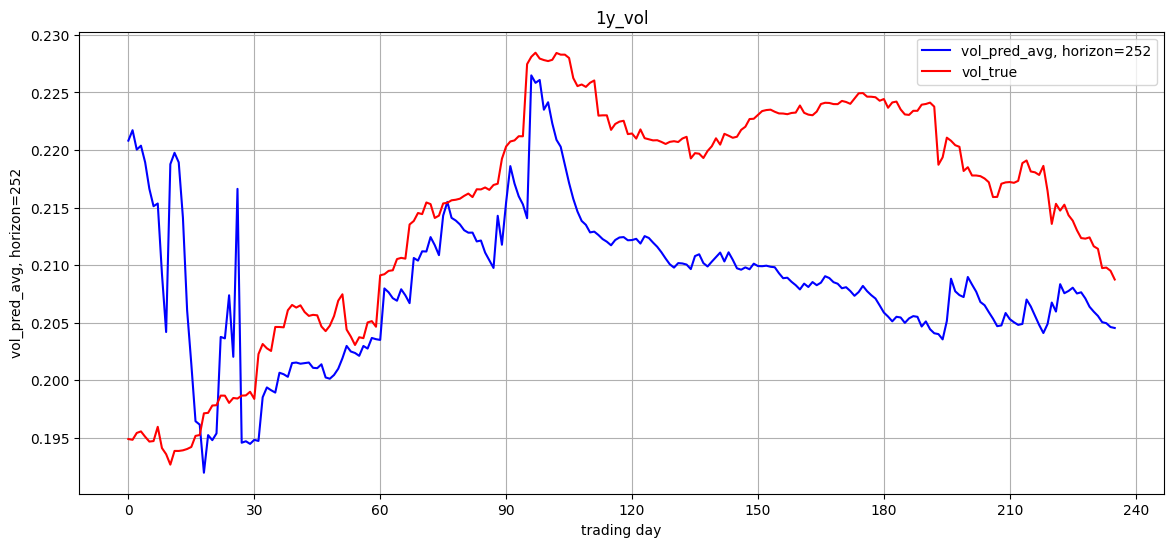

In [56]:
os.makedirs('volatility_plots', exist_ok=True)

for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], vals[-488+pred_char_to_value(expiry_date):], f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', graphtitle=f'{expiry_date}_vol', show=False)
    _, _ = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], df[f'{expiry_date}_vol'][-488+pred_char_to_value(expiry_date):], 'vol_true', linecolor='red', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_true_garch_fair.png', dpi=300)
    plt.close(fig)

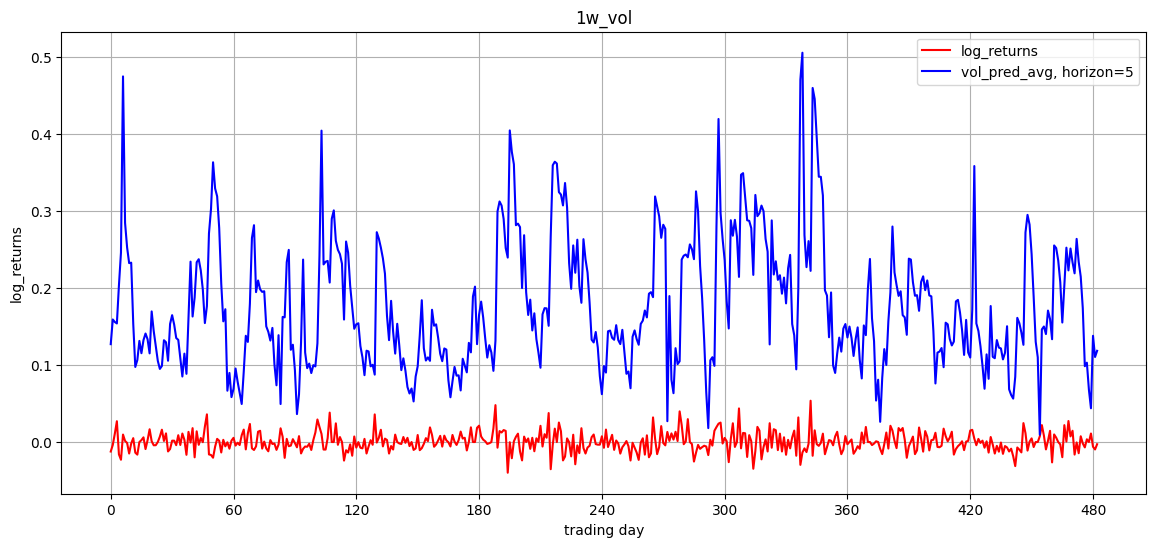

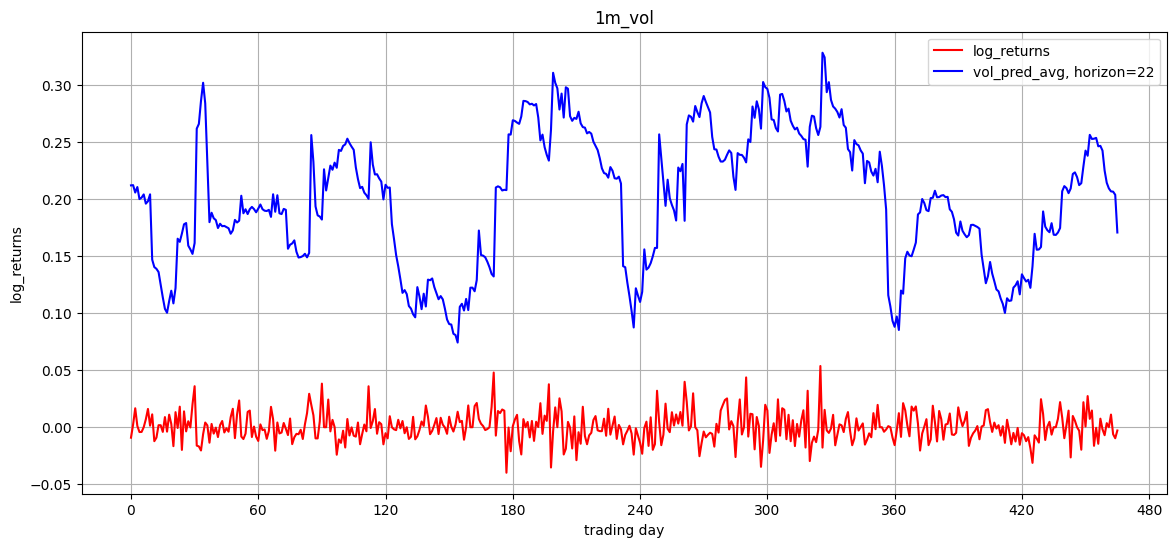

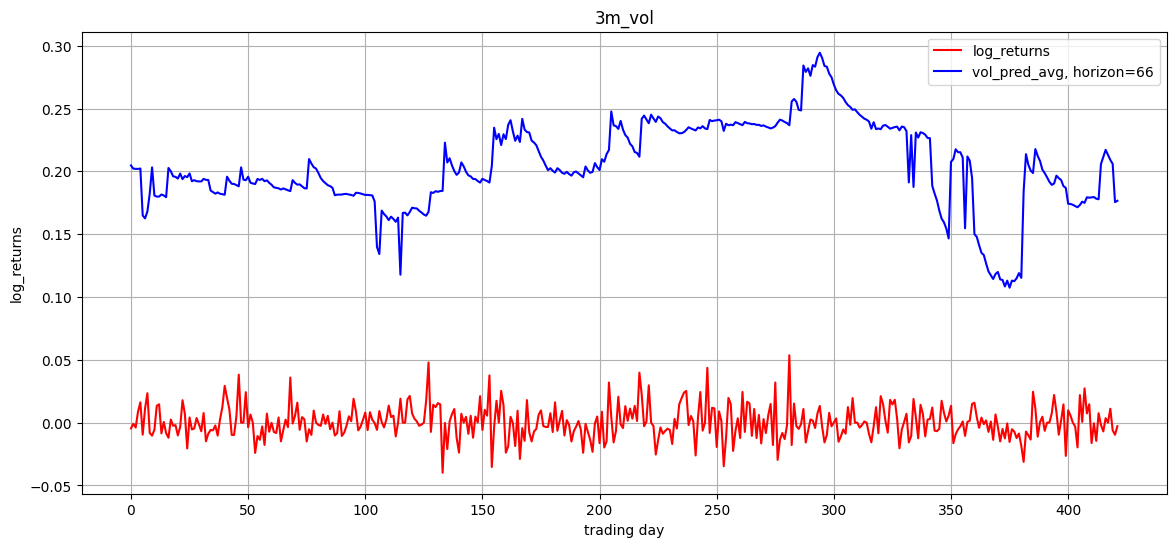

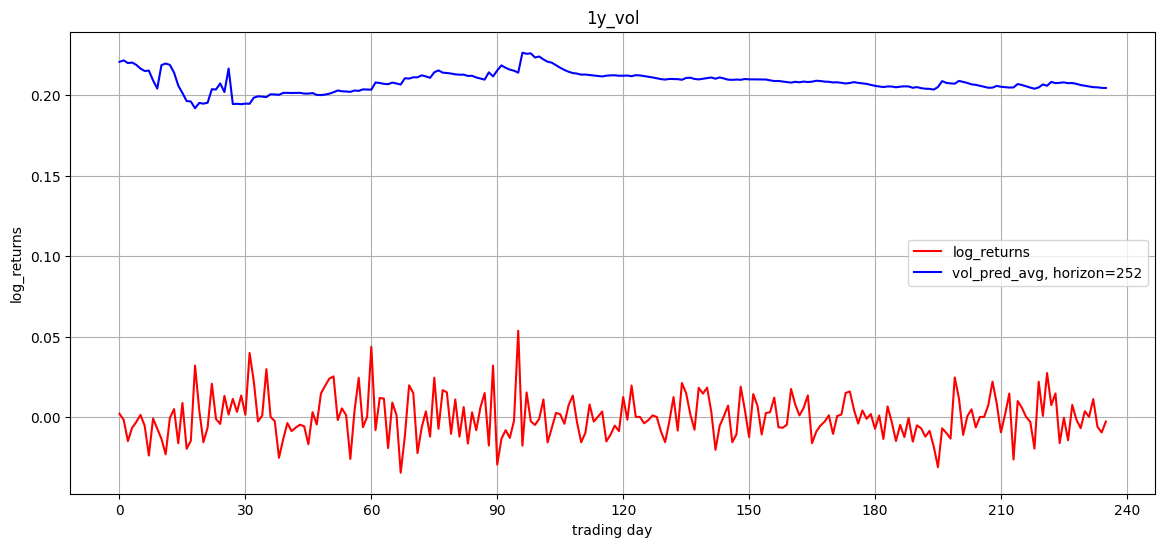

In [57]:
for expiry_date, vals in avg_pred_volatilities_test.items():
    ax, fig = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], df[f'al_lme_prices_log_returns'][-488+pred_char_to_value(expiry_date):], 'log_returns', graphtitle=f'{expiry_date}_vol', linecolor='red', show=False)
    _, _ = line_plot(df['date'][-488+pred_char_to_value(expiry_date):], vals[-488+pred_char_to_value(expiry_date):], f'vol_pred_avg, horizon={pred_char_to_value(expiry_date)}', ax=ax, show=True)
    plt.show()
    fig.savefig(f'volatility_plots/{expiry_date}_vol_vs_log_returns_garch_fair.png', dpi=300)
    plt.close(fig)